# 🔆 Simulación Monte Carlo para Hosting Capacity de Generación PV

## Análisis Probabilístico en Redes de Distribución

Este notebook implementa el método completo de Monte Carlo para determinar la **Hosting Capacity (HC)** de generadores fotovoltaicos distribuidos en una red de distribución eléctrica de baja tensión.

### Contenido:
1. **Modelo simplificado de red** (ejecutable sin OpenDSS)
2. **Distribuciones de probabilidad** para las variables aleatorias
3. **Simulación Monte Carlo completa** con análisis temporal
4. **Análisis estadístico**: convergencia, probabilidad de violación, HC por barra
5. **Visualización** de todos los resultados
6. **Integración con OpenDSS** (código de referencia)

> **Basado en:** Santos Junior et al., "Study of the hosting capacity of photovoltaic distributed generators in low voltage distribution networks: A probabilistic approach using Monte Carlo simulations" (IJAERS, 2022)


## 1. Configuración e importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)

# Estilo de graficas
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 2. Modelo de la Red de Distribución

### 2.1 Topología

Modelamos una red de baja tensión (BT) real basada en el paper:
- **Transformador**: 75 kVA, 13.8 kV / 380-220 V
- **7 barras** (buses) en configuración radial
- **20 consumidores** monofásicos distribuidos en las 7 barras
- **885 metros** de línea total

La red es **radial**: una línea principal sale del transformador y alimenta las barras secuencialmente. Las barras más lejanas (Bus 5, 6, 7) tienen mayor impedancia acumulada.

### Modelo eléctrico simplificado

Usamos la ecuación fundamental de caída de voltaje:

$$\Delta V \approx \frac{P \cdot R + Q \cdot X}{|V|^2}$$

Para cada segmento de línea entre barras consecutivas.


In [2]:
# ============================================================
# MODELO DE LA RED DE DISTRIBUCIÓN
# ============================================================

class RedDistribucion:
    """
    Modelo simplificado de una red de distribución radial de BT.
    
    Topología: Trafo -> Bus1 -> Bus2 -> ... -> Bus7
    Cada bus tiene cargas monofásicas conectadas.
    
    El modelo resuelve el flujo de potencia usando la aproximación
    de caída de voltaje: ΔV ≈ (P·R + Q·X) / |V|²
    """
    
    def __init__(self):
        # --- Parámetros del transformador ---
        self.S_trafo_kVA = 75        # Potencia nominal [kVA]
        self.V_primario = 13800      # Voltaje primario [V]
        self.V_secundario = 220      # Voltaje secundario L-N [V]
        self.Z_trafo_pu = 0.04       # Impedancia del trafo [p.u.]
        
        # --- Parámetros de las líneas ---
        # Impedancia por metro [Ohm/m] (cable típico de aluminio BT)
        self.r_por_metro = 0.000320  # Resistencia
        self.x_por_metro = 0.000080  # Reactancia
        
        # Longitud de cada segmento entre barras [metros]
        self.longitudes = {
            (0, 1): 50,    # Trafo -> Bus1
            (1, 2): 100,   # Bus1 -> Bus2
            (2, 3): 120,   # Bus2 -> Bus3
            (3, 4): 150,   # Bus3 -> Bus4
            (4, 5): 165,   # Bus4 -> Bus5
            (5, 6): 150,   # Bus5 -> Bus6
            (6, 7): 150,   # Bus6 -> Bus7
        }
        
        # --- Cargas por bus ---
        # Cada CU tiene potencia nominal [kW] y fase (1, 2 o 3)
        self.cargas = {
            1: [{'kW': 1.5, 'fase': 1}, {'kW': 1.2, 'fase': 2}],
            2: [{'kW': 1.8, 'fase': 3}, {'kW': 1.3, 'fase': 1}, 
                {'kW': 1.0, 'fase': 2}],
            3: [{'kW': 2.0, 'fase': 1}, {'kW': 1.5, 'fase': 2},
                {'kW': 1.7, 'fase': 3}, {'kW': 1.1, 'fase': 1}],
            4: [{'kW': 1.6, 'fase': 2}, {'kW': 1.4, 'fase': 3}],
            5: [{'kW': 1.9, 'fase': 1}, {'kW': 1.3, 'fase': 2},
                {'kW': 1.5, 'fase': 3}],
            6: [{'kW': 1.7, 'fase': 1}, {'kW': 2.0, 'fase': 2},
                {'kW': 1.2, 'fase': 3}],
            7: [{'kW': 1.8, 'fase': 1}, {'kW': 1.5, 'fase': 2},
                {'kW': 1.6, 'fase': 3}],
        }
        
        # Mapeo: indice de CU -> (bus, indice en bus)
        self.cu_map = []
        for bus, cargas_bus in self.cargas.items():
            for idx, carga in enumerate(cargas_bus):
                self.cu_map.append({
                    'cu_id': len(self.cu_map),
                    'bus': bus,
                    'idx_en_bus': idx,
                    'fase': carga['fase'],
                    'kW_nominal': carga['kW']
                })
        
        self.N_CU = len(self.cu_map)
        self.N_buses = 7
        
        # Precalcular impedancias acumuladas desde el trafo
        self._calcular_impedancias()
    
    def _calcular_impedancias(self):
        """Calcula R y X acumulados desde el trafo hasta cada bus."""
        self.R_acum = {0: 0.0}  # Bus 0 = trafo (referencia)
        self.X_acum = {0: 0.0}
        
        # Impedancia del transformador (referida al secundario)
        Z_base = self.V_secundario**2 / (self.S_trafo_kVA * 1000)
        R_trafo = self.Z_trafo_pu * Z_base * 0.3   # ~30% resistivo
        X_trafo = self.Z_trafo_pu * Z_base * 0.95   # ~95% reactivo
        
        self.R_acum[0] = R_trafo
        self.X_acum[0] = X_trafo
        
        for bus in range(1, self.N_buses + 1):
            L = self.longitudes.get((bus-1, bus), 100)
            self.R_acum[bus] = self.R_acum[bus-1] + self.r_por_metro * L
            self.X_acum[bus] = self.X_acum[bus-1] + self.x_por_metro * L
    
    def resolver_flujo(self, pv_generadores=None, factor_carga=1.0, 
                       factor_solar=1.0):
        """
        Resuelve el flujo de potencia simplificado.
        
        Parámetros:
        -----------
        pv_generadores : list of dict
            [{'cu_id': int, 'kW': float}, ...]
        factor_carga : float
            Multiplicador de la curva de carga (0 a 1)
        factor_solar : float
            Multiplicador de la curva solar (0 a 1)
        
        Retorna:
        --------
        dict con voltajes por bus y fase, potencia del trafo, etc.
        """
        if pv_generadores is None:
            pv_generadores = []
        
        V_base = self.V_secundario  # 220 V
        
        # Potencia neta por bus y fase [W]
        P_neto = {}  # {(bus, fase): watts}
        Q_neto = {}
        
        for bus in range(1, self.N_buses + 1):
            for carga in self.cargas[bus]:
                key = (bus, carga['fase'])
                # Carga consume (positivo)
                P_neto[key] = P_neto.get(key, 0) + carga['kW'] * 1000 * factor_carga
                Q_neto[key] = Q_neto.get(key, 0) + carga['kW'] * 300 * factor_carga  # PF~0.95
        
        # PV inyecta (negativo = reduce potencia neta)
        for pv in pv_generadores:
            cu = self.cu_map[pv['cu_id']]
            key = (cu['bus'], cu['fase'])
            P_neto[key] = P_neto.get(key, 0) - pv['kW'] * 1000 * factor_solar
            # PV a unity PF: Q_pv = 0
        
        # Calcular voltajes usando ΔV ≈ (P·R + Q·X) / V²
        voltajes = {}  # {(bus, fase): V_pu}
        P_trafo_total = 0
        
        for bus in range(1, self.N_buses + 1):
            R = self.R_acum[bus]
            X = self.X_acum[bus]
            
            for fase in [1, 2, 3]:
                key = (bus, fase)
                P = P_neto.get(key, 0)
                Q = Q_neto.get(key, 0)
                
                # ΔV = (P·R + Q·X) / V²
                delta_V = (P * R + Q * X) / (V_base**2)
                V_pu = 1.0 - delta_V / V_base
                
                voltajes[key] = V_pu
                P_trafo_total += P
        
        # Calcular desbalance por bus
        desbalance = {}
        for bus in range(1, self.N_buses + 1):
            V = [voltajes.get((bus, f), 1.0) for f in [1, 2, 3]]
            V_avg = np.mean(V)
            if V_avg > 0:
                max_dev = max(abs(v - V_avg) for v in V)
                desbalance[bus] = (max_dev / V_avg) * 100
            else:
                desbalance[bus] = 0
        
        return {
            'voltajes': voltajes,        # {(bus, fase): V_pu}
            'desbalance': desbalance,     # {bus: %}
            'P_trafo_kW': P_trafo_total / 1000,
            'P_neto': P_neto
        }

# Instanciar la red
red = RedDistribucion()
print(f"Red creada: {red.N_buses} buses, {red.N_CU} consumidores")
print(f"\nImpedancia acumulada (Ω) desde el transformador:")
print(f"{'Bus':>5} {'R (mΩ)':>10} {'X (mΩ)':>10} {'|Z| (mΩ)':>10}")
print("-" * 40)
for bus in range(1, red.N_buses + 1):
    R = red.R_acum[bus] * 1000
    X = red.X_acum[bus] * 1000
    Z = np.sqrt(R**2 + X**2)
    print(f"{bus:>5} {R:>10.1f} {X:>10.1f} {Z:>10.1f}")


Red creada: 7 buses, 20 consumidores

Impedancia acumulada (Ω) desde el transformador:
  Bus     R (mΩ)     X (mΩ)   |Z| (mΩ)
----------------------------------------
    1       23.7       28.5       37.1
    2       55.7       36.5       66.6
    3       94.1       46.1      104.8
    4      142.1       58.1      153.6
    5      194.9       71.3      207.6
    6      242.9       83.3      256.8
    7      290.9       95.3      306.2


## 3. Curvas Temporales: Carga e Irradiancia Solar

El análisis Monte Carlo incluye variación temporal a lo largo de un día completo (1440 minutos). Necesitamos dos curvas:

1. **Curva de irradiancia solar**: producción PV normalizada (0 a 1)
2. **Curva de carga residencial**: consumo normalizado (0 a 1)

El **momento crítico** ocurre alrededor del mediodía, cuando la producción solar es máxima pero el consumo residencial es bajo → máximo excedente de potencia → máximo sobrevoltaje.


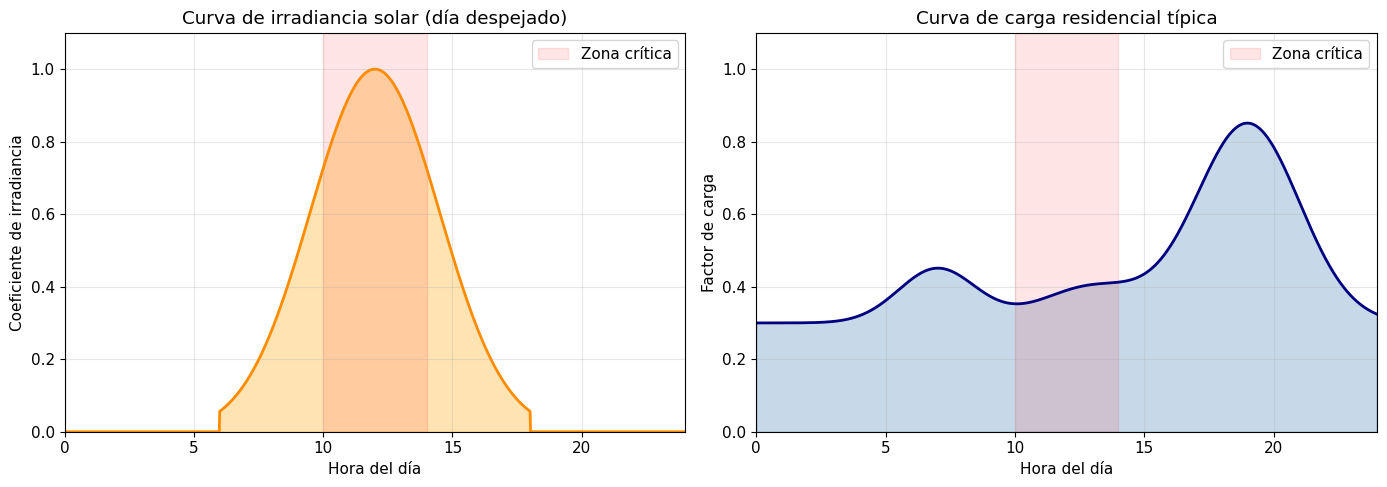


⚠️  Momento más crítico: 11.8h
   Solar = 0.998, Carga = 0.386
   Excedente relativo = 0.612


In [3]:
# ============================================================
# CURVAS TEMPORALES (1440 minutos = 24 horas)
# ============================================================

minutos = np.arange(1440)
horas = minutos / 60

def curva_solar(t_min):
    """
    Curva de irradiancia solar para un día despejado.
    Forma de campana gaussiana centrada al mediodía.
    Retorna coeficiente entre 0 y 1.
    """
    hora = t_min / 60
    # Amanecer ~6h, ocaso ~18h, pico ~12h
    if hora < 6 or hora > 18:
        return 0.0
    # Gaussiana centrada en 12h
    return np.exp(-0.5 * ((hora - 12) / 2.5)**2)

def curva_carga(t_min):
    """
    Curva de carga residencial típica brasileña.
    Pico ~18-20h, mínimo ~3-5h.
    Retorna factor entre 0.2 y 1.0.
    """
    hora = t_min / 60
    # Componentes: base + pico matutino + pico nocturno
    base = 0.3
    pico_manana = 0.15 * np.exp(-0.5 * ((hora - 7) / 1.5)**2)
    pico_noche = 0.55 * np.exp(-0.5 * ((hora - 19) / 2.0)**2)
    medio_dia = 0.10 * np.exp(-0.5 * ((hora - 13) / 2.0)**2)
    return min(base + pico_manana + pico_noche + medio_dia, 1.0)

# Vectorizar
solar_array = np.array([curva_solar(t) for t in minutos])
carga_array = np.array([curva_carga(t) for t in minutos])

# --- GRAFICAR ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva solar
axes[0].fill_between(horas, solar_array, alpha=0.3, color='orange')
axes[0].plot(horas, solar_array, color='darkorange', linewidth=2)
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Coeficiente de irradiancia')
axes[0].set_title('Curva de irradiancia solar (día despejado)')
axes[0].set_xlim(0, 24)
axes[0].set_ylim(0, 1.1)
axes[0].axvspan(10, 14, alpha=0.1, color='red', label='Zona crítica')
axes[0].legend()

# Curva de carga
axes[1].fill_between(horas, carga_array, alpha=0.3, color='steelblue')
axes[1].plot(horas, carga_array, color='navy', linewidth=2)
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Factor de carga')
axes[1].set_title('Curva de carga residencial típica')
axes[1].set_xlim(0, 24)
axes[1].set_ylim(0, 1.1)
axes[1].axvspan(10, 14, alpha=0.1, color='red', label='Zona crítica')
axes[1].legend()

plt.tight_layout()
plt.show()

# Mostrar el momento crítico
idx_critico = np.argmax(solar_array - carga_array)
print(f"\n⚠️  Momento más crítico: {horas[idx_critico]:.1f}h")
print(f"   Solar = {solar_array[idx_critico]:.3f}, Carga = {carga_array[idx_critico]:.3f}")
print(f"   Excedente relativo = {solar_array[idx_critico] - carga_array[idx_critico]:.3f}")


## 4. Distribuciones de Probabilidad para Monte Carlo

Las dos variables aleatorias principales:
1. **Punto de conexión**: distribución uniforme (todos los CUs tienen la misma probabilidad)
2. **Potencia PV**: distribución empírica basada en datos reales de ANEEL


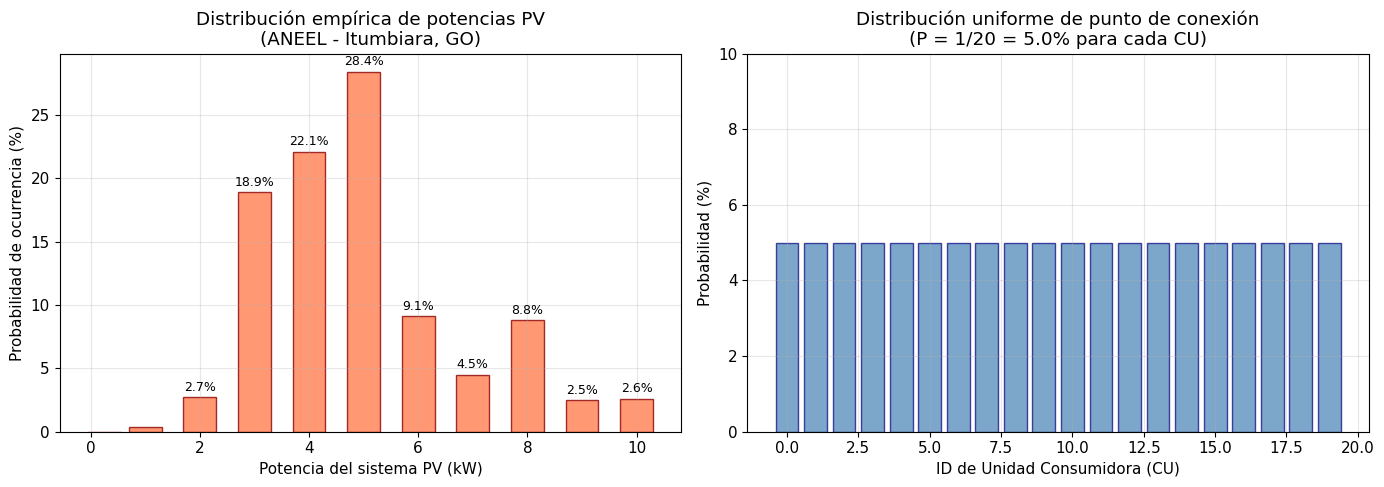


Estadísticas de la distribución de potencias PV:
  Media:    4.98 kW
  Desv.std: 1.84 kW
  Moda:     5 kW (más probable)


In [4]:
# ============================================================
# DISTRIBUCIONES DE PROBABILIDAD
# ============================================================

# Distribución empírica de potencias PV (datos ANEEL, Itumbiara-GO)
potencias_kw =    [0.25,  1,     2,     3,     4,     5,     6,     7,     8,     9,     10]
probabilidades =  [0.000, 0.004, 0.027, 0.189, 0.221, 0.284, 0.091, 0.045, 0.088, 0.025, 0.026]

# Verificar que sumen 1
prob_array = np.array(probabilidades)
prob_array = prob_array / prob_array.sum()  # Normalizar

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de potencias
bars = axes[0].bar(potencias_kw, prob_array * 100, width=0.6, 
                    color='coral', edgecolor='darkred', alpha=0.8)
axes[0].set_xlabel('Potencia del sistema PV (kW)')
axes[0].set_ylabel('Probabilidad de ocurrencia (%)')
axes[0].set_title('Distribución empírica de potencias PV\n(ANEEL - Itumbiara, GO)')
for bar, p in zip(bars, prob_array):
    if p > 0.01:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{p*100:.1f}%', ha='center', fontsize=9)

# Distribución uniforme de puntos de conexión
cu_ids = range(red.N_CU)
axes[1].bar(cu_ids, [1/red.N_CU * 100] * red.N_CU, 
            color='steelblue', edgecolor='navy', alpha=0.7)
axes[1].set_xlabel('ID de Unidad Consumidora (CU)')
axes[1].set_ylabel('Probabilidad (%)')
axes[1].set_title(f'Distribución uniforme de punto de conexión\n(P = 1/{red.N_CU} = {1/red.N_CU*100:.1f}% para cada CU)')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

# Estadísticas
potencia_media = np.average(potencias_kw, weights=prob_array)
potencia_std = np.sqrt(np.average((np.array(potencias_kw) - potencia_media)**2, weights=prob_array))
print(f"\nEstadísticas de la distribución de potencias PV:")
print(f"  Media:    {potencia_media:.2f} kW")
print(f"  Desv.std: {potencia_std:.2f} kW")
print(f"  Moda:     {potencias_kw[np.argmax(prob_array)]} kW (más probable)")


## 5. Simulación Monte Carlo Completa

### El algoritmo:

Para cada **nivel de penetración** (PL = 0%, 10%, ..., 100%):
- Repetir **N_MCS** veces:
  1. Elegir aleatoriamente qué CUs tendrán PV
  2. Asignar potencia aleatoria a cada PV
  3. Para cada minuto del día (o muestreo reducido):
     - Resolver flujo de potencia
     - Registrar voltajes, desbalance, potencia del trafo
  4. Verificar si hubo violaciones

### ⚡ Optimización:
En lugar de simular los 1440 minutos, muestreamos los **momentos críticos** (10:00 a 14:00) donde el excedente solar es máximo. Esto reduce el costo computacional ~6x sin perder precisión en la detección de violaciones.


In [5]:
# ============================================================
# SIMULACIÓN MONTE CARLO
# ============================================================

# Parámetros de simulación
N_MCS = 300            # Simulaciones Monte Carlo por nivel
PL_levels = np.arange(0, 110, 10)  # 0% a 100%, paso 10%
V_MAX = 1.05           # Límite superior de voltaje [p.u.]
V_MIN = 0.92           # Límite inferior (PRODIST)
FD_MAX = 3.0           # Límite de desbalance [%]

# Momentos a simular (minutos) - zona crítica + pico nocturno
t_muestreo = list(range(540, 900, 15)) + list(range(1020, 1260, 30))
# ~9h a 15h cada 15 min + 17h a 21h cada 30 min

print(f"Parámetros de simulación:")
print(f"  N_MCS = {N_MCS} simulaciones por nivel de penetración")
print(f"  Niveles PL = {list(PL_levels)}%")
print(f"  {len(t_muestreo)} instantes de tiempo por simulación")
print(f"  Total flujos de potencia: {len(PL_levels) * N_MCS * len(t_muestreo):,}")
print(f"\nLímites:")
print(f"  Voltaje: {V_MIN} ≤ V_pu ≤ {V_MAX}")
print(f"  Desbalance: FD ≤ {FD_MAX}%")
print(f"  Trafo: S ≤ {red.S_trafo_kVA} kVA")


Parámetros de simulación:
  N_MCS = 300 simulaciones por nivel de penetración
  Niveles PL = [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]%
  32 instantes de tiempo por simulación
  Total flujos de potencia: 105,600

Límites:
  Voltaje: 0.92 ≤ V_pu ≤ 1.05
  Desbalance: FD ≤ 3.0%
  Trafo: S ≤ 75 kVA


In [6]:
# ============================================================
# EJECUCIÓN DE LA SIMULACIÓN
# ============================================================
from time import time

# Almacenamiento de resultados
resultados_todos = []       # Todos los datos detallados
resumen_por_mcs = []        # Resumen por simulación

t_inicio = time()

for pl_idx, pl in enumerate(PL_levels):
    n_pv = int(pl * red.N_CU / 100)
    
    for mcs in range(N_MCS):
        # --- PASO 1: Generar escenario aleatorio ---
        if n_pv > 0:
            # Elegir CUs al azar
            cus_con_pv = np.random.choice(
                red.N_CU, size=n_pv, replace=False
            )
            # Elegir potencias al azar
            pots_pv = np.random.choice(
                potencias_kw, size=n_pv, p=prob_array
            )
            generadores = [
                {'cu_id': int(cu), 'kW': float(kw)}
                for cu, kw in zip(cus_con_pv, pots_pv)
            ]
        else:
            generadores = []
        
        # --- PASO 2: Simular en instantes críticos ---
        max_v = 0
        min_v = 2
        max_fd = 0
        max_p_trafo = 0
        min_p_trafo = 999
        tiene_violacion_v = False
        tiene_violacion_fd = False
        tiene_violacion_trafo = False
        
        for t in t_muestreo:
            f_carga = curva_carga(t)
            f_solar = curva_solar(t)
            
            res = red.resolver_flujo(
                pv_generadores=generadores,
                factor_carga=f_carga,
                factor_solar=f_solar
            )
            
            # Analizar voltajes
            for (bus, fase), v_pu in res['voltajes'].items():
                if v_pu > max_v:
                    max_v = v_pu
                if v_pu < min_v:
                    min_v = v_pu
                if v_pu > V_MAX or v_pu < V_MIN:
                    tiene_violacion_v = True
                    
                    resultados_todos.append({
                        'PL': pl, 'MCS': mcs, 
                        'Bus': bus, 'Fase': fase,
                        'V_pu': v_pu, 't_min': t,
                        'Tipo': 'voltaje'
                    })
            
            # Analizar desbalance
            for bus, fd in res['desbalance'].items():
                if fd > max_fd:
                    max_fd = fd
                if fd > FD_MAX:
                    tiene_violacion_fd = True
            
            # Analizar potencia del trafo
            p_trafo = abs(res['P_trafo_kW'])
            if p_trafo > max_p_trafo:
                max_p_trafo = p_trafo
            if res['P_trafo_kW'] < min_p_trafo:
                min_p_trafo = res['P_trafo_kW']
            if p_trafo > red.S_trafo_kVA:
                tiene_violacion_trafo = True
        
        # --- PASO 3: Almacenar resumen ---
        pot_total_pv = sum(g['kW'] for g in generadores) if generadores else 0
        
        resumen_por_mcs.append({
            'PL': pl,
            'MCS': mcs,
            'N_PV': n_pv,
            'kW_PV_total': pot_total_pv,
            'V_max': max_v,
            'V_min': min_v,
            'FD_max': max_fd,
            'P_trafo_max_kW': max_p_trafo,
            'P_trafo_min_kW': min_p_trafo,
            'Viol_V': tiene_violacion_v,
            'Viol_FD': tiene_violacion_fd,
            'Viol_Trafo': tiene_violacion_trafo,
            'Viol_cualquiera': tiene_violacion_v or tiene_violacion_fd or tiene_violacion_trafo
        })
    
    elapsed = time() - t_inicio
    print(f"  PL={pl:>3}% completado ({n_pv:>2} PVs) | "
          f"Tiempo: {elapsed:.1f}s")

df_resumen = pd.DataFrame(resumen_por_mcs)
df_violaciones = pd.DataFrame(resultados_todos) if resultados_todos else pd.DataFrame()

print(f"\n✅ Simulación completada en {time()-t_inicio:.1f} segundos")
print(f"   Total registros resumen: {len(df_resumen):,}")
print(f"   Total violaciones detectadas: {len(df_violaciones):,}")


  PL=  0% completado ( 0 PVs) | Tiempo: 1.0s


  PL= 10% completado ( 2 PVs) | Tiempo: 1.9s


  PL= 20% completado ( 4 PVs) | Tiempo: 2.9s


  PL= 30% completado ( 6 PVs) | Tiempo: 4.1s


  PL= 40% completado ( 8 PVs) | Tiempo: 5.3s


...

  PL= 60% completado (12 PVs) | Tiempo: 7.3s


  PL= 70% completado (14 PVs) | Tiempo: 8.6s


  PL= 80% completado (16 PVs) | Tiempo: 9.7s


  PL= 90% completado (18 PVs) | Tiempo: 10.7s


  PL=100% completado (20 PVs) | Tiempo: 11.7s

✅ Simulación completada en 11.7 segundos
   Total registros resumen: 3,300
   Total violaciones detectadas: 0


## 6. Análisis de Convergencia

¿Son suficientes 300 simulaciones? Verificamos con el **Coeficiente de Variación (CV)**:

$$CV = \frac{\sigma}{\mu \times \sqrt{n}}$$

Cuando el CV se estabiliza, las simulaciones adicionales no aportan información significativa.


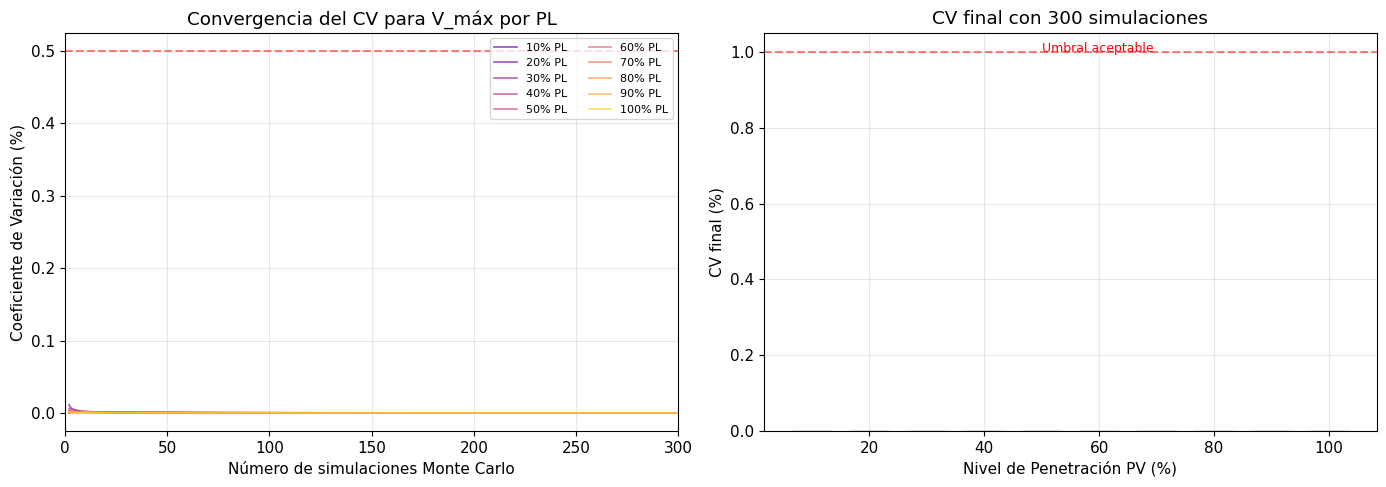


CV finales por nivel de penetración:
  ✅ PL=10%: CV = 0.000%
  ✅ PL=20%: CV = 0.000%
  ✅ PL=30%: CV = 0.000%
  ✅ PL=40%: CV = 0.000%
  ✅ PL=50%: CV = 0.000%
  ✅ PL=60%: CV = 0.000%
  ✅ PL=70%: CV = 0.000%
  ✅ PL=80%: CV = 0.000%
  ✅ PL=90%: CV = 0.000%
  ✅ PL=100%: CV = 0.000%


In [7]:
# ============================================================
# ANÁLISIS DE CONVERGENCIA (CV)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV del voltaje máximo para diferentes PLs
colores_pl = plt.cm.plasma(np.linspace(0.1, 0.9, len(PL_levels)))

for pl, color in zip(PL_levels[1:], colores_pl[1:]):  # Skip 0%
    datos_pl = df_resumen[df_resumen['PL'] == pl]['V_max'].values
    
    cv_historia = []
    for n in range(2, len(datos_pl) + 1):
        subset = datos_pl[:n]
        sigma = np.std(subset, ddof=1)
        mu = np.mean(subset)
        cv = sigma / (mu * np.sqrt(n)) * 100 if mu > 0 else 0
        cv_historia.append(cv)
    
    axes[0].plot(range(2, len(datos_pl) + 1), cv_historia,
                label=f'{pl}% PL', color=color, alpha=0.7, linewidth=1.2)

axes[0].set_xlabel('Número de simulaciones Monte Carlo')
axes[0].set_ylabel('Coeficiente de Variación (%)')
axes[0].set_title('Convergencia del CV para V_máx por PL')
axes[0].legend(fontsize=8, ncol=2, loc='upper right')
axes[0].set_xlim(0, N_MCS)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='CV = 0.5%')

# CV final por PL
cv_finales = {}
for pl in PL_levels[1:]:
    datos = df_resumen[df_resumen['PL'] == pl]['V_max'].values
    sigma = np.std(datos, ddof=1)
    mu = np.mean(datos)
    cv_finales[pl] = sigma / (mu * np.sqrt(len(datos))) * 100 if mu > 0 else 0

axes[1].bar(cv_finales.keys(), cv_finales.values(), width=7,
           color='teal', edgecolor='darkslategray', alpha=0.8)
axes[1].set_xlabel('Nivel de Penetración PV (%)')
axes[1].set_ylabel('CV final (%)')
axes[1].set_title(f'CV final con {N_MCS} simulaciones')
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
axes[1].annotate('Umbral aceptable', xy=(50, 1.0), color='red', fontsize=9)

plt.tight_layout()
plt.show()

print("\nCV finales por nivel de penetración:")
for pl, cv in cv_finales.items():
    estado = "✅" if cv < 1.0 else "⚠️"
    print(f"  {estado} PL={pl}%: CV = {cv:.3f}%")


## 7. Resultados: Probabilidad de Violación y Hosting Capacity

### 7.1 Probabilidad de violación por nivel de penetración

Este es el resultado central del análisis Monte Carlo: para cada PL, ¿cuál es la probabilidad de que ocurra al menos una violación?


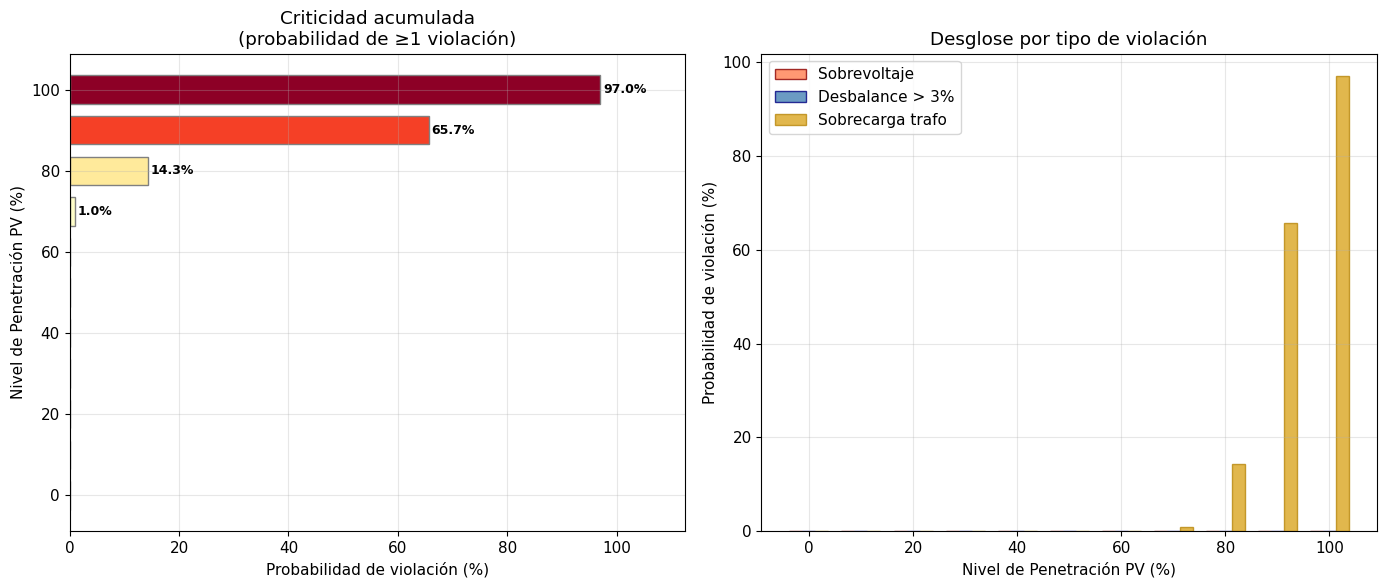


  HOSTING CAPACITY DE LA RED
  HC (   Voltaje): PL = 100% (prob. violación ≤ 5.0%)
  HC (Desbalance): PL = 100% (prob. violación ≤ 5.0%)
  HC (     Trafo): PL = 70% (prob. violación ≤ 5.0%)
  HC (    Global): PL = 70% (prob. violación ≤ 5.0%)

  ➡️  HC FINAL = 70% de penetración PV
      (criterio: probabilidad de violación ≤ 5.0%)


In [8]:
# ============================================================
# PROBABILIDAD DE VIOLACIÓN POR PL
# ============================================================

prob_v = df_resumen.groupby('PL')['Viol_V'].mean() * 100
prob_fd = df_resumen.groupby('PL')['Viol_FD'].mean() * 100
prob_trafo = df_resumen.groupby('PL')['Viol_Trafo'].mean() * 100
prob_cualquiera = df_resumen.groupby('PL')['Viol_cualquiera'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales (criticidad acumulada - como Fig.11 del paper)
colores_barras = plt.cm.YlOrRd(prob_cualquiera.values / 100)
bars = axes[0].barh(prob_cualquiera.index, prob_cualquiera.values,
                     height=7, color=colores_barras, edgecolor='gray')
axes[0].set_xlabel('Probabilidad de violación (%)')
axes[0].set_ylabel('Nivel de Penetración PV (%)')
axes[0].set_title('Criticidad acumulada\n(probabilidad de ≥1 violación)')
axes[0].set_xlim(0, max(prob_cualquiera.values) * 1.15 + 1)

for bar, val in zip(bars, prob_cualquiera.values):
    if val > 0:
        axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Desglose por tipo de violación
x = PL_levels
width = 2.5
axes[1].bar(x - width, prob_v.values, width, label='Sobrevoltaje', 
            color='coral', edgecolor='darkred', alpha=0.8)
axes[1].bar(x, prob_fd.values, width, label='Desbalance > 3%',
            color='steelblue', edgecolor='navy', alpha=0.8)
axes[1].bar(x + width, prob_trafo.values, width, label='Sobrecarga trafo',
            color='goldenrod', edgecolor='darkgoldenrod', alpha=0.8)
axes[1].set_xlabel('Nivel de Penetración PV (%)')
axes[1].set_ylabel('Probabilidad de violación (%)')
axes[1].set_title('Desglose por tipo de violación')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Identificar HC ---
print("\n" + "="*55)
print("  HOSTING CAPACITY DE LA RED")
print("="*55)
umbral = 5.0  # % de probabilidad aceptable
for nombre, prob_serie in [('Voltaje', prob_v), ('Desbalance', prob_fd), 
                            ('Trafo', prob_trafo), ('Global', prob_cualquiera)]:
    hc_pls = prob_serie[prob_serie <= umbral].index
    hc = hc_pls.max() if len(hc_pls) > 0 else 0
    print(f"  HC ({nombre:>10}): PL = {hc}% "
          f"(prob. violación ≤ {umbral}%)")

print(f"\n  ➡️  HC FINAL = {prob_cualquiera[prob_cualquiera <= umbral].index.max()}% "
      f"de penetración PV")
print(f"      (criterio: probabilidad de violación ≤ {umbral}%)")


### 7.2 Análisis por barra

Las barras más lejanas del transformador (Bus 5, 6, 7) deberían tener más violaciones porque tienen mayor impedancia acumulada.


No se detectaron violaciones de voltaje en las simulaciones.


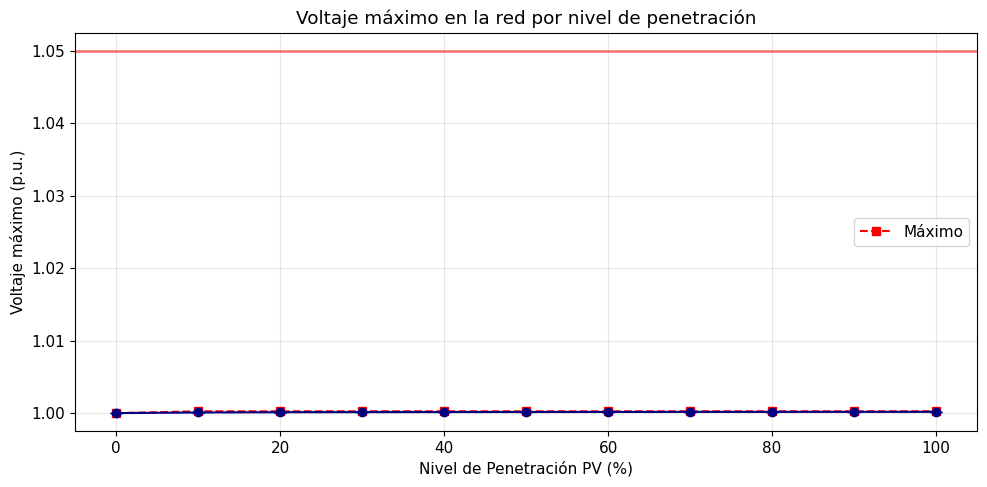

In [9]:
# ============================================================
# VIOLACIONES POR BARRA
# ============================================================

if not df_violaciones.empty and 'Bus' in df_violaciones.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Violaciones por barra y PL
    viol_por_bus_pl = df_violaciones.groupby(['PL', 'Bus']).size().unstack(fill_value=0)
    
    cmap = plt.cm.Set2
    buses_unicos = sorted(df_violaciones['Bus'].unique())
    for i, bus in enumerate(buses_unicos):
        if bus in viol_por_bus_pl.columns:
            axes[0].plot(viol_por_bus_pl.index, viol_por_bus_pl[bus],
                        'o-', label=f'Bus {bus}', color=cmap(i), linewidth=2)
    
    axes[0].set_xlabel('Nivel de Penetración PV (%)')
    axes[0].set_ylabel('Número de violaciones')
    axes[0].set_title('Violaciones de voltaje por barra y PL')
    axes[0].legend()
    
    # Voltaje máximo por bus
    v_max_bus = df_resumen.groupby('PL')['V_max'].agg(['mean', 'max', 
                                                         lambda x: np.percentile(x, 95)])
    v_max_bus.columns = ['Media', 'Máximo', 'P95']
    
    axes[1].fill_between(v_max_bus.index, v_max_bus['Media'], v_max_bus['P95'],
                         alpha=0.3, color='coral')
    axes[1].plot(v_max_bus.index, v_max_bus['Media'], 'o-', color='navy',
                linewidth=2, label='Media')
    axes[1].plot(v_max_bus.index, v_max_bus['P95'], 's--', color='coral',
                linewidth=1.5, label='Percentil 95')
    axes[1].plot(v_max_bus.index, v_max_bus['Máximo'], '^:', color='red',
                linewidth=1, label='Máximo absoluto')
    axes[1].axhline(y=V_MAX, color='red', linestyle='-', linewidth=2, 
                    alpha=0.7, label=f'Límite ({V_MAX} p.u.)')
    axes[1].set_xlabel('Nivel de Penetración PV (%)')
    axes[1].set_ylabel('Voltaje máximo (p.u.)')
    axes[1].set_title('Voltaje máximo en la red por PL')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron violaciones de voltaje en las simulaciones.")
    # Graficar voltajes máximos de todas formas
    fig, ax = plt.subplots(figsize=(10, 5))
    v_max_stats = df_resumen.groupby('PL')['V_max'].agg(['mean', 'max', 'std'])
    ax.errorbar(v_max_stats.index, v_max_stats['mean'], 
                yerr=v_max_stats['std'], fmt='o-', capsize=4, color='navy')
    ax.plot(v_max_stats.index, v_max_stats['max'], 's--', color='red', label='Máximo')
    ax.axhline(y=V_MAX, color='red', linestyle='-', linewidth=2, alpha=0.5)
    ax.set_xlabel('Nivel de Penetración PV (%)')
    ax.set_ylabel('Voltaje máximo (p.u.)')
    ax.set_title('Voltaje máximo en la red por nivel de penetración')
    ax.legend()
    plt.tight_layout()
    plt.show()


### 7.3 Carga del transformador

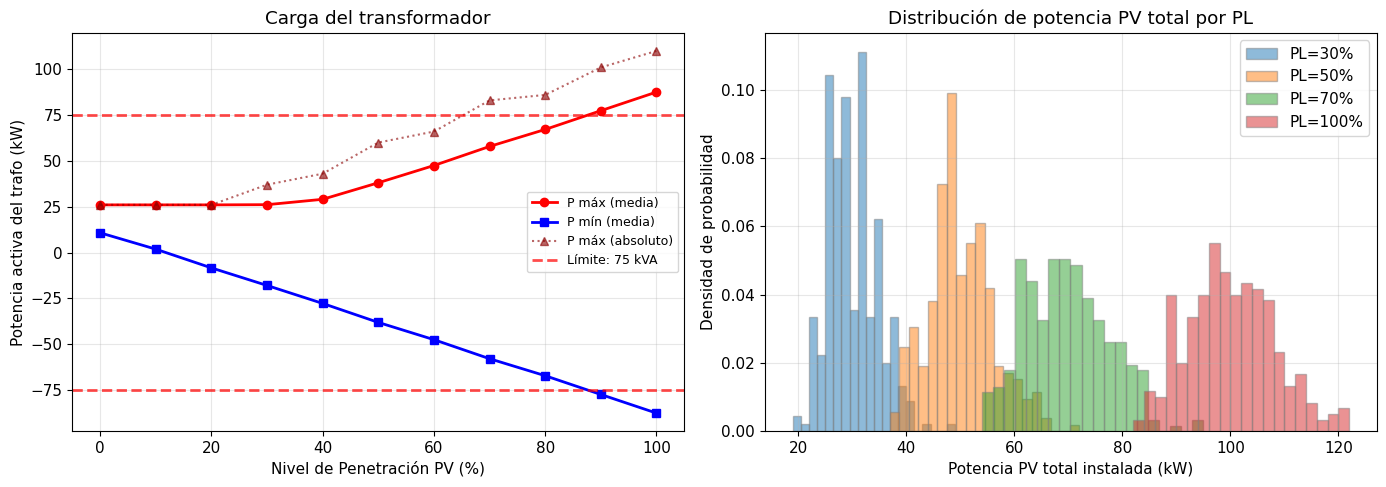

In [10]:
# ============================================================
# ANÁLISIS DEL TRANSFORMADOR
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Potencia máxima, media y mínima del trafo por PL
trafo_stats = df_resumen.groupby('PL').agg({
    'P_trafo_max_kW': ['mean', 'max'],
    'P_trafo_min_kW': ['mean', 'min'],
    'kW_PV_total': 'mean'
}).round(2)

axes[0].plot(PL_levels, trafo_stats[('P_trafo_max_kW', 'mean')], 
            'o-', color='red', label='P máx (media)', linewidth=2)
axes[0].plot(PL_levels, trafo_stats[('P_trafo_min_kW', 'mean')],
            's-', color='blue', label='P mín (media)', linewidth=2)
axes[0].plot(PL_levels, trafo_stats[('P_trafo_max_kW', 'max')],
            '^:', color='darkred', label='P máx (absoluto)', alpha=0.6)
axes[0].axhline(y=red.S_trafo_kVA, color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Límite: {red.S_trafo_kVA} kVA')
axes[0].axhline(y=-red.S_trafo_kVA, color='red', linestyle='--', 
                linewidth=2, alpha=0.7)
axes[0].set_xlabel('Nivel de Penetración PV (%)')
axes[0].set_ylabel('Potencia activa del trafo (kW)')
axes[0].set_title('Carga del transformador')
axes[0].legend(fontsize=9)

# Distribución de potencia PV total instalada por PL
for pl in [30, 50, 70, 100]:
    data = df_resumen[df_resumen['PL'] == pl]['kW_PV_total']
    if len(data) > 0:
        axes[1].hist(data, bins=20, alpha=0.5, label=f'PL={pl}%', 
                    density=True, edgecolor='gray')

axes[1].set_xlabel('Potencia PV total instalada (kW)')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].set_title('Distribución de potencia PV total por PL')
axes[1].legend()

plt.tight_layout()
plt.show()


### 7.4 Distribución de voltajes máximos

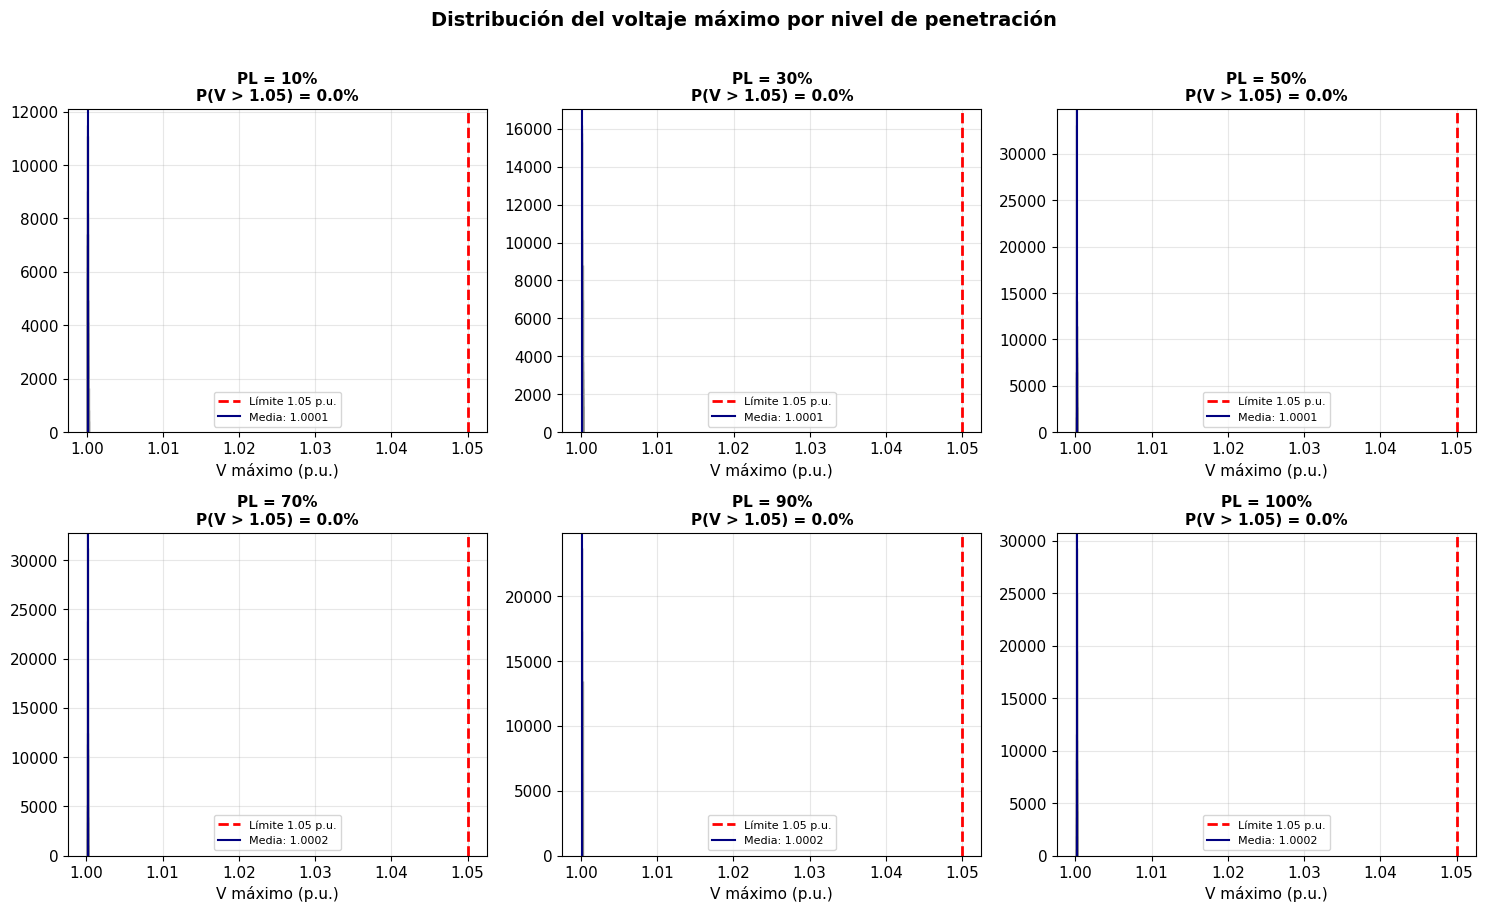

In [11]:
# ============================================================
# HISTOGRAMAS DE VOLTAJE MÁXIMO POR PL
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

pls_mostrar = [10, 30, 50, 70, 90, 100]

for ax, pl in zip(axes, pls_mostrar):
    data = df_resumen[df_resumen['PL'] == pl]['V_max']
    
    n_viol = (data > V_MAX).sum()
    prob = n_viol / len(data) * 100
    
    color = 'coral' if prob > 5 else 'steelblue'
    
    ax.hist(data, bins=30, color=color, edgecolor='gray', 
            alpha=0.7, density=True)
    ax.axvline(x=V_MAX, color='red', linewidth=2, linestyle='--',
              label=f'Límite {V_MAX} p.u.')
    ax.axvline(x=data.mean(), color='navy', linewidth=1.5, linestyle='-',
              label=f'Media: {data.mean():.4f}')
    
    ax.set_title(f'PL = {pl}%\n'
                f'P(V > {V_MAX}) = {prob:.1f}%',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('V máximo (p.u.)')
    ax.legend(fontsize=8)

plt.suptitle('Distribución del voltaje máximo por nivel de penetración',
            fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 8. Integración con OpenDSS (Código de Referencia)

El modelo simplificado anterior es útil para entender el método, pero para estudios reales se usa **OpenDSS** como motor de flujo de potencia. Aquí está el código de referencia para conectar Monte Carlo con OpenDSS.

> ⚠️ Este código requiere tener OpenDSS instalado y el módulo `dss` de Python. No se ejecuta en este notebook pero está listo para copiar a tu entorno.


In [12]:
# ============================================================
# CODIGO DE REFERENCIA: MONTE CARLO + OPENDSS
# ============================================================
# NO EJECUTAR AQUI - requiere OpenDSS instalado
# Copiar a un entorno con OpenDSS para usar

import numpy as np
# import dss  # Descomentar cuando OpenDSS este instalado
import pandas as pd

# === INICIALIZAR OPENDSS ===
# engine = dss.DSS
# engine.Start(0)
# text = engine.Text
# circuit = engine.ActiveCircuit

# === DISTRIBUCION DE POTENCIAS (ANEEL) ===
pot_kw = [0.25, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
prob = [0.0, 0.004, 0.027, 0.189, 0.221,
        0.284, 0.091, 0.045, 0.088, 0.025, 0.026]
prob = np.array(prob) / sum(prob)

def cargar_circuito():
    text.Command = "Clear"
    text.Command = "Redirect mi_red_BT.dss"
    text.Command = "Solve"

def agregar_pv(bus, fase, kw, idx):
    kv = 0.220
    text.Command = (
        f"New Generator.PV{idx} "
        f"Bus1={bus}.{fase} Phases=1 "
        f"kV={kv} kW={kw} kvar=0 Model=1 daily=Solar"
    )

def leer_voltajes():
    resultados = []
    for barra in circuit.AllBusNames:
        circuit.SetActiveBus(barra)
        pu = circuit.ActiveBus.puVoltages
        nodos = circuit.ActiveBus.Nodes
        for idx in range(len(nodos)):
            real, imag = pu[2*idx], pu[2*idx+1]
            mag = (real**2 + imag**2)**0.5
            resultados.append({"Barra": barra, "Fase": nodos[idx], "V_pu": round(mag, 6)})
    return resultados

print("Codigo OpenDSS cargado (comentado para no ejecutar)")
print("Descomentar las lineas de engine/text/circuit para usar")


Codigo OpenDSS cargado (comentado para no ejecutar)
Descomentar las lineas de engine/text/circuit para usar


## 9. Resumen y Conclusiones

### Flujo completo del análisis:

```
┌─────────────────────────────────────────────────────────┐
│  VARIABLES ALEATORIAS (Monte Carlo)                     │
│  • Punto de conexión PV → Dist. uniforme                │
│  • Potencia PV → Dist. empírica (ANEEL)                 │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  MODELO DETERMINISTA (OpenDSS / Modelo simplificado)    │
│  • Ecuaciones de flujo de potencia                      │
│  • ΔV ≈ (P·R + Q·X) / |V|²                             │
│  • Resolución para cada minuto del día                  │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  VERIFICACIÓN DE LÍMITES                                │
│  • Voltaje: 0.92 ≤ V_pu ≤ 1.05                         │
│  • Desbalance: FD ≤ 3%                                  │
│  • Transformador: S ≤ S_nominal                         │
└──────────────────────┬──────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────┐
│  ANÁLISIS ESTADÍSTICO (500 simulaciones × 11 PLs)       │
│  • Convergencia (CV)                                    │
│  • Probabilidad de violación por PL                     │
│  • HC = PL máximo con prob. violación ≤ 5%              │
└─────────────────────────────────────────────────────────┘
```

### Ecuaciones clave usadas:

| Concepto | Ecuación |
|----------|----------|
| Subida de voltaje | $\Delta V \approx (P \cdot R + Q \cdot X) / |V|^2$ |
| Factor de potencia | $PF = \cos\phi = P / |S|$ |
| Desbalance | $FD\% = |V_-| / |V_+| \times 100$ |
| Convergencia MC | $CV = \sigma / (\mu \times \sqrt{n})$ |
| Probabilidad de violación | $P(viol) = N_{viol} / N_{MCS}$ |
| Hosting Capacity | $HC = \max\{PL : P(viol|PL) \leq 5\%\}$ |


In [13]:
# ============================================================
# TABLA RESUMEN FINAL
# ============================================================

print("=" * 60)
print("  RESUMEN DE HOSTING CAPACITY")
print("=" * 60)
print(f"  Red: {red.N_buses} buses, {red.N_CU} consumidores")
print(f"  Transformador: {red.S_trafo_kVA} kVA")
print(f"  Simulaciones: {N_MCS} MCS × {len(PL_levels)} niveles PL")
print(f"  Instantes temporales: {len(t_muestreo)} por simulación")
print()

tabla = df_resumen.groupby('PL').agg({
    'V_max': ['mean', 'max'],
    'FD_max': 'max',
    'Viol_cualquiera': 'mean'
}).round(4)

tabla.columns = ['V_max_medio', 'V_max_absoluto', 
                 'FD_max', 'Prob_violacion']
tabla['Prob_violacion'] = (tabla['Prob_violacion'] * 100).round(2)

print(tabla.to_string())
print()

# HC final
umbral = 5.0
hc_final = tabla[tabla['Prob_violacion'] <= umbral].index.max()
print(f"\n  ✅ HOSTING CAPACITY = {hc_final}% de penetración PV")
print(f"     (con umbral de {umbral}% de probabilidad de violación)")
print(f"     Equivale a ~{int(hc_final * red.N_CU / 100)} PVs en una red de {red.N_CU} CUs")


  RESUMEN DE HOSTING CAPACITY
  Red: 7 buses, 20 consumidores
  Transformador: 75 kVA
  Simulaciones: 300 MCS × 11 niveles PL
  Instantes temporales: 32 por simulación

     V_max_medio  V_max_absoluto  FD_max  Prob_violacion
PL                                                      
0         1.0000          1.0000  0.0013            0.00
10        1.0001          1.0003  0.0183            0.00
20        1.0001          1.0003  0.0184            0.00
30        1.0001          1.0003  0.0183            0.00
40        1.0001          1.0003  0.0180            0.00
50        1.0001          1.0003  0.0184            0.00
60        1.0002          1.0003  0.0184            0.00
70        1.0002          1.0003  0.0166            1.00
80        1.0002          1.0003  0.0175           14.33
90        1.0002          1.0003  0.0166           65.67
100       1.0002          1.0003  0.0120           97.00


  ✅ HOSTING CAPACITY = 70% de penetración PV
     (con umbral de 5.0% de probabilidad de